<a href="https://colab.research.google.com/github/anubhav123456/Deep-Learning/blob/main/2.%20MP%20Neuron/MP_Neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import Libraries

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Step 2: Load Dataset

In [2]:
# Load Breast Cancer Dataset
breast_cancer_data = load_breast_cancer();

In [3]:
print("Feature Names:")
print(breast_cancer_data.feature_names)

print("\nTarget Names:")
print(breast_cancer_data.target_names)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']


In [4]:
X = breast_cancer_data.data;        # Features
Y = breast_cancer_data.target;      # Labels (0 = Malignant, 1 = Benign)

In [5]:
print("Shape of X:", X.shape);
print("Shape of y:", Y.shape);

Shape of X: (569, 30)
Shape of y: (569,)


In [6]:
data = pd.DataFrame(data=X, columns=breast_cancer_data.feature_names);

In [7]:
data['class'] = Y;

In [8]:
display(data.head());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
print(data['class'].value_counts());

class
1    357
0    212
Name: count, dtype: int64


In [10]:
print(breast_cancer_data.target_names);

['malignant' 'benign']


In [11]:
display(data.groupby('class').mean());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
class,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


# Step 3: Train-Test Split

In [12]:
X = data.drop('class', axis=1);
Y = data['class'];

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, stratify=Y, random_state=42);

In [14]:
print("Inputs: ", X.shape, X_train.shape, X_test.shape);
print("Outputs: ", Y.shape, y_train.shape, y_test.shape);

Inputs:  (569, 30) (512, 30) (57, 30)
Outputs:  (569,) (512,) (57,)


# Plotting

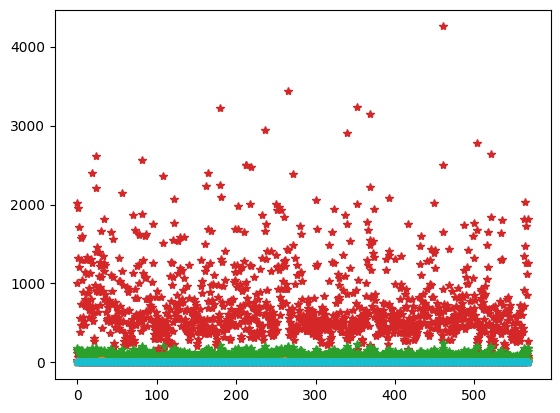

In [15]:
plt.plot(X, '*');
plt.show();

In [16]:
display(X_train.head());

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
413,14.99,22.11,97.53,693.7,0.08515,0.10250,0.06859,0.03876,0.1944,0.05913,...,16.76,31.55,110.20,867.1,0.1077,0.33450,0.3114,0.13080,0.3163,0.09251
517,19.89,20.26,130.50,1214.0,0.10370,0.13100,0.14110,0.09431,0.1802,0.06188,...,23.73,25.23,160.50,1646.0,0.1417,0.33090,0.4185,0.16130,0.2549,0.09136
245,10.48,19.86,66.72,337.7,0.10700,0.05971,0.04831,0.03070,0.1737,0.06440,...,11.48,29.46,73.68,402.8,0.1515,0.10260,0.1181,0.06736,0.2883,0.07748
102,12.18,20.52,77.22,458.7,0.08013,0.04038,0.02383,0.01770,0.1739,0.05677,...,13.34,32.84,84.58,547.8,0.1123,0.08862,0.1145,0.07431,0.2694,0.06878
28,15.30,25.27,102.40,732.4,0.10820,0.16970,0.16830,0.08751,0.1926,0.06540,...,20.27,36.71,149.30,1269.0,0.1641,0.61100,0.6335,0.20240,0.4027,0.09876


In [17]:
display(X_train.T.head());

,413,517,245,102,28,65,398,409,145,99,...,85,499,487,184,300,509,230,354,103,248
mean radius,14.99000,19.8900,10.480,12.18000,15.3000,14.7800,11.06000,12.27000,11.9000,14.42000,...,18.46000,20.5900,19.4400,15.28000,19.530,15.4600,17.0500,11.14000,9.8760,10.65000
mean texture,22.11000,20.2600,19.860,20.52000,25.2700,23.9400,14.83000,17.92000,14.6500,19.77000,...,18.52000,21.2400,18.8200,22.41000,18.900,23.9500,19.0800,14.07000,19.4000,25.22000
mean perimeter,97.53000,130.5000,66.720,77.22000,102.4000,97.4000,70.31000,78.41000,78.1100,94.48000,...,121.10000,137.8000,128.1000,98.92000,129.500,103.8000,113.4000,71.24000,63.9500,68.01000
mean area,693.70000,1214.0000,337.700,458.70000,732.4000,668.3000,378.20000,466.10000,432.8000,642.50000,...,1075.00000,1320.0000,1167.0000,710.60000,1217.000,731.3000,895.0000,384.60000,298.3000,347.00000
mean smoothness,0.08515,0.1037,0.107,0.08013,0.1082,0.1172,0.07741,0.08685,0.1152,0.09752,...,0.09874,0.1085,0.1089,0.09057,0.115,0.1183,0.1141,0.07274,0.1005,0.09657


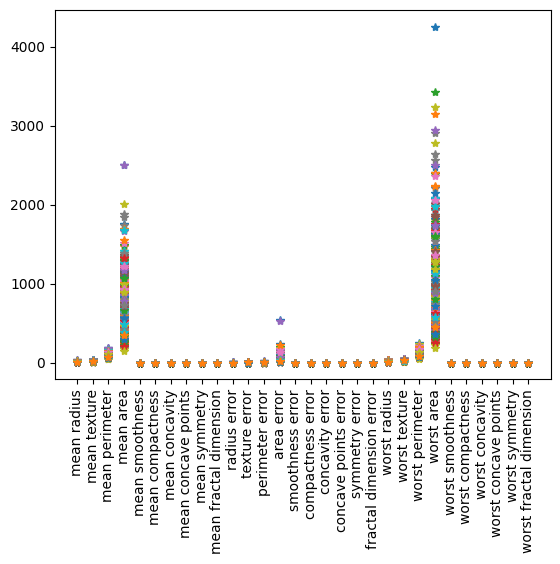

In [18]:
plt.plot(X_train.T, '*')
plt.xticks(rotation='vertical')
plt.show()

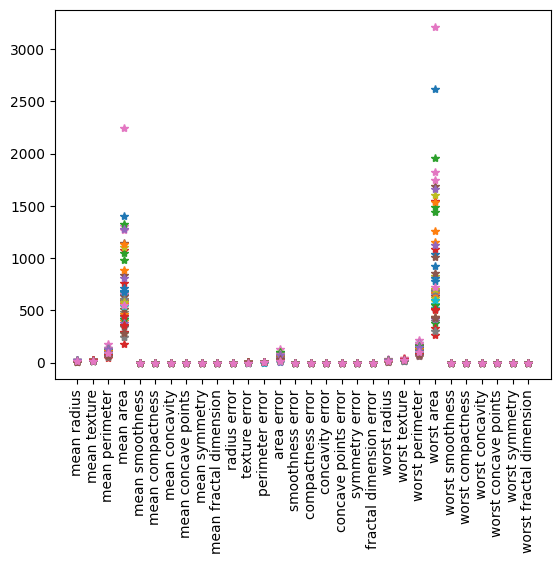

In [19]:
plt.plot(X_test.T, '*')
plt.xticks(rotation='vertical')
plt.show()

# Step 4: Binarisation

In [20]:
X_binarised_train = X_train.apply(pd.cut, bins=2, labels=[1,0]);
X_binarised_test = X_test.apply(pd.cut, bins=2, labels=[1, 0]);

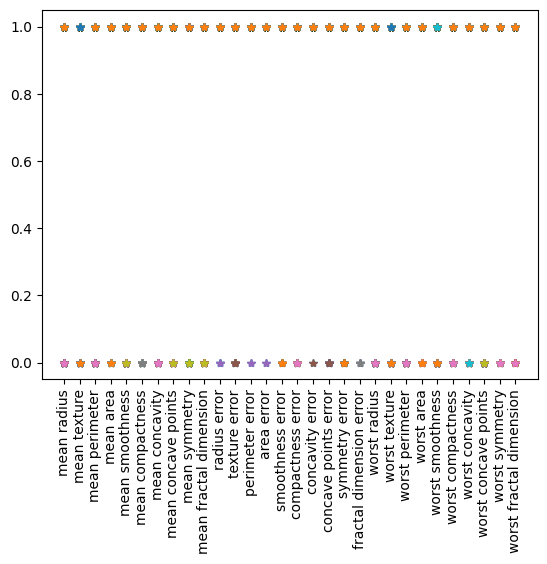

In [21]:
plt.plot(X_binarised_train.T, '*')
plt.xticks(rotation='vertical')
plt.show()

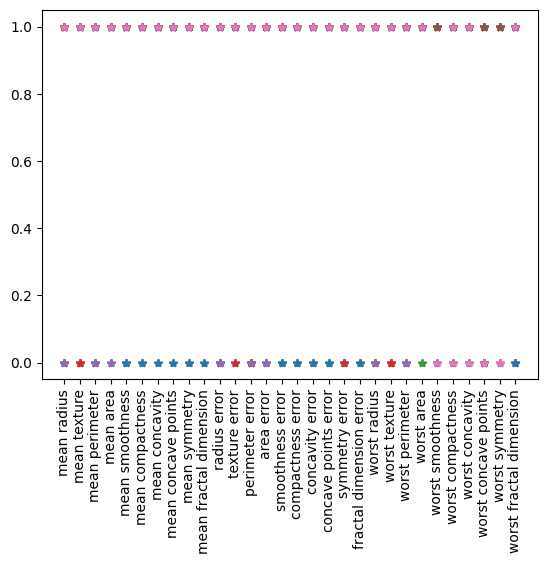

In [22]:
plt.plot(X_binarised_test.T, '*')
plt.xticks(rotation='vertical')
plt.show()

# Step 5: Dataframe to Numpy conversion

In [23]:
X_binarised_test = X_binarised_test.values;
X_binarised_train = X_binarised_train.values;
y_train = y_train.values;
y_test = y_test.values;

# Step 6: Model

In [24]:
class MPNeuron:

    def __init__(self):

        self.threshold = None;

    def activation(self, z):

        return np.where(np.sum(z) >= self.threshold, 1, 0);

    def predict(self, X):

      predictions = [];

      for x in X:

        y_pred = self.activation(x);
        predictions.append(y_pred);

      return np.array(predictions);

    def score(self, y_pred, y_true):

      return accuracy_score(y_pred, y_true);

    def fit(self, X, Y):

      acc = {};

      for threshold in range(X.shape[1] + 1):
        self.threshold = threshold;
        y_pred = self.predict(X);
        acc[threshold] = self.score(y_pred, Y);

      best_threshold = max(acc, key=acc.get);
      self.threshold = best_threshold;

      return self.threshold;



# Step 7: Prediction



In [25]:
mp_neuron_model = MPNeuron();
best_threshold = mp_neuron_model.fit(X_binarised_train, y_train);
print("Best Threshold:", best_threshold);

Best Threshold: 27


In [26]:
y_pred_train = mp_neuron_model.predict(X_binarised_train);
y_pred_test = mp_neuron_model.predict(X_binarised_test);
train_accuracy = mp_neuron_model.score(y_pred_train, y_train)
test_accuracy = mp_neuron_model.score(y_pred_test, y_test)

print("Train Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

Train Accuracy : 0.861328125
Test Accuracy  : 0.8421052631578947
